# AI-Generated Video Detection: Robustness Analysis

**Authors**: Alessandro Sartore 256152

**Date**: February 2026  

**Objective**: Evaluate the effectiveness of augmentation strategies for improving fake video detector generalization to SOTA generators.

---

## Introduction

This notebook implements and evaluates various techniques from recent deepfake detection literature:

1. **Wavelet-based augmentation** (Corvi et al., "Intriguing Properties of Synthetic Images")
2. **Forensic augmentation pipeline** (Corvi et al., "Seeing What Matters")
3. **Spatial attention & temporal consistency** (Battocchio et al., "Pyramid Flow Detection")

### Research Questions:
- Q1: Which augmentation strategies improve generalization?
- Q2: How do models trained on simple fakes perform on SOTA generators?
- Q3: What artifacts distinguish real from SOTA fake videos?

---

## 1.1 Imports and Environment Setup

Import all required libraries

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

import numpy as np
import pandas as pd
import cv2 
import pywt  # Wavelet transforms
import timm  # Vision Transformer backbones
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import glob
import os
import json
import io
from PIL import Image
from sklearn.model_selection import train_test_split

# Set random seeds for reproducibility
RANDOM_SEED = 33
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("All libraries imported successfully")

All libraries imported successfully


## 1.2 Device Configuration and Hyperparameters

Configure CUDA device and set training hyperparameters aligned with the literature.

In [ ]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Hyperparameters (aligned with Battocchio et al. and Corvi et al.)
NUM_FRAMES = 8        # Temporal batch size
IMG_SIZE = 224        # Standard ViT input size
BATCH_SIZE = 8        # Reduced for memory constraints
LEARNING_RATE = 1e-4  # Adam optimizer learning rate
NUM_EPOCHS = 10       # Training epochs

print(f"\nConfiguration:")
print(f"Frames per video: {NUM_FRAMES}")
print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")

Using device: cuda
GPU: NVIDIA GeForce RTX 4060
Memory: 8.59 GB

Configuration:
Frames per video: 8
Image size: 224x224
Batch size: 8
Learning rate: 0.0001


## 1.3 Dataset Loading and Splitting

Load real and fake videos, balance classes, and create train/validation split.

**Dataset Structure:**
- `datasets/real/` - Real videos
- `datasets/fake_pyramid/` - Fake videos (training set)
- `datasets/fake_sota/` - SOTA fake videos (test set)

In [18]:
# Create output directories
os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

# Load training data
print("Loading dataset...")
real_paths = sorted(glob.glob("datasets/real/*.mp4"))
fake_paths = sorted(glob.glob("datasets/fake_pyramid/*.mp4"))

if len(real_paths) == 0 or len(fake_paths) == 0:
    raise ValueError("No videos found! Check dataset paths.")

print(f"Found {len(real_paths)} real videos")
print(f"Found {len(fake_paths)} fake videos")

# Balance classes
min_len = min(len(real_paths), len(fake_paths))
real_paths = real_paths[:min_len]
fake_paths = fake_paths[:min_len]

# Combine and create labels
all_paths = real_paths + fake_paths
all_labels = [0] * len(real_paths) + [1] * len(fake_paths)  # 0=real, 1=fake

# Train/validation split (80/20)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths, all_labels, 
    test_size=0.2, 
    random_state=42, 
    stratify=all_labels
)

print(f"\nDataset split:")
print(f"Training: {len(train_paths)} videos ({sum(train_labels)} fake, {len(train_labels)-sum(train_labels)} real)")
print(f"Validation: {len(val_paths)} videos ({sum(val_labels)} fake, {len(val_labels)-sum(val_labels)} real)")

# Check for SOTA test set
sota_fake_paths = sorted(glob.glob("datasets/fake_sota/*.mp4"))
if len(sota_fake_paths) > 0:
    print(f"SOTA Test: {len(sota_fake_paths)} videos")
else:
    print(f"No SOTA test set found (optional)")

Loading dataset...
Found 450 real videos
Found 450 fake videos

Dataset split:
Training: 720 videos (360 fake, 360 real)
Validation: 180 videos (90 fake, 90 real)
SOTA Test: 41 videos


---

# Part 2: Data Augmentation Techniques

## 2.1 Wavelet-Based Augmentation

**Reference**: Corvi et al., "Intriguing Properties of Synthetic Images"

**Idea**: Fake images contain high-frequency artifacts in the diagonal wavelet component. To reduce semantic bias, we blend fake frames with real frames by:
1. Decompose both frames using Haar wavelet
2. Keep **diagonal details (cD)** from fake (contains artifacts)
3. Replace approximation and H/V details with real frame
4. Reconstruct the augmented frame

This forces the model to focus on generation artifacts rather than semantic content.

In [19]:
def wavelet_blend(fake_frame, real_frame):
    """
    Applies Haar Wavelet decomposition and blends fake diagonal artifacts
    with real frame content to reduce semantic bias.
    
    Args:
        fake_frame: torch.Tensor [C, H, W] - Fake video frame
        real_frame: torch.Tensor [C, H, W] - Real video frame for blending
        
    Returns:
        torch.Tensor [C, H, W] - Augmented frame with mixed components
    """
    # Convert to numpy [H, W, C]
    fake_np = fake_frame.detach().cpu().numpy().transpose(1, 2, 0) 
    real_np = real_frame.detach().cpu().numpy().transpose(1, 2, 0)
    
    aug_frame = np.zeros_like(fake_np)
    
    # Process each color channel independently
    for ch in range(3): 
        # 2D Haar wavelet decomposition
        coeffs_fake = pywt.dwt2(fake_np[:,:,ch], 'haar')
        coeffs_real = pywt.dwt2(real_np[:,:,ch], 'haar')
        
        # Extract components:
        # cA = Approximation (low frequencies, semantic content)
        # cH = Horizontal details
        # cV = Vertical details  
        # cD = Diagonal details (HIGH-FREQUENCY ARTIFACTS!)
        cA_fake, (cH_fake, cV_fake, cD_fake) = coeffs_fake
        cA_real, (cH_real, cV_real, cD_real) = coeffs_real
        
        # MIXING STRATEGY:
        # Keep cD from FAKE (generation artifacts)
        # Replace cA, cH, cV with REAL (remove semantic bias)
        new_coeffs = (cA_real, (cH_real, cV_real, cD_fake)) 
        
        # Inverse wavelet transform
        rec = pywt.idwt2(new_coeffs, 'haar')
        
        # Handle dimension mismatch (wavelet may change size by 1 pixel)
        h, w = fake_np.shape[:2]
        aug_frame[:,:,ch] = rec[:h, :w]
        
    # Clip to valid range [0, 1]
    aug_frame = np.clip(aug_frame, 0.0, 1.0)
        
    # Convert back to tensor [C, H, W]
    return torch.from_numpy(aug_frame.transpose(2, 0, 1)).float()

print("Wavelet blend augmentation implemented")

Wavelet blend augmentation implemented


## 2.2 Forensic Augmentation Pipeline

**Reference**: Corvi et al., "Seeing What Matters"

**Motivation**: Detectors often fail when videos undergo post-processing (compression, resizing, blur). We simulate these transformations during training to improve robustness.

**5 Techniques**:
1. **JPEG Compression** - Simulate social media compression
2. **Gaussian Blur** - Camera blur, downsampling artifacts
3. **Gaussian Noise** - Sensor noise, transmission errors
4. **Resize Artifacts** - Scaling up/down with quality loss
5. **Color Jitter** - Brightness/contrast/saturation changes

**Strategy**: Apply 1-2 random augmentations per frame (mixing strategy from paper)

In [20]:
class ForensicAugmentation:
    """
    Forensic-oriented augmentation pipeline for robustness to post-processing.
    Implements 5 techniques from "Seeing What Matters" paper.
    """
    
    def __init__(self):
        # Parameter ranges from paper
        self.jpeg_qualities = [70, 75, 80, 85, 90, 95]
        self.blur_kernels = [(3,3), (5,5), (7,7)]
        self.noise_levels = [0.01, 0.02, 0.03, 0.05]
        self.resize_factors = [0.7, 0.8, 0.9, 1.1, 1.2]
        
    def jpeg_compression(self, frame):
        """Simulate JPEG compression with random quality (70-95)"""
        quality = int(np.random.choice(self.jpeg_qualities))  
        
        # Convert tensor [C,H,W] to numpy [H,W,C] in range [0,255]
        frame_np = (frame.cpu().numpy().transpose(1,2,0) * 255).astype(np.uint8)
        
        # Encode/decode through JPEG buffer
        pil_img = Image.fromarray(frame_np)
        buffer = io.BytesIO()
        pil_img.save(buffer, format='JPEG', quality=quality)
        buffer.seek(0)
        compressed = Image.open(buffer)
        
        # Convert back to tensor [C,H,W] in range [0,1]
        result = np.array(compressed).astype(np.float32) / 255.0
        return torch.from_numpy(result.transpose(2,0,1)).float()
    
    def gaussian_blur(self, frame):
        """Apply Gaussian blur with random kernel size (3x3, 5x5, 7x7)"""
        kernel = int(np.random.choice([3, 5, 7])) 
        frame_np = frame.cpu().numpy().transpose(1,2,0)
        blurred = cv2.GaussianBlur(frame_np, (kernel, kernel), 0)
        return torch.from_numpy(blurred.transpose(2,0,1)).float()
    
    def gaussian_noise(self, frame):
        """Add Gaussian noise (sigma=0.01 to 0.05)"""
        noise_level = float(np.random.choice(self.noise_levels)) 
        noise = torch.randn_like(frame) * noise_level
        return torch.clamp(frame + noise, 0, 1)
    
    def resize_artifact(self, frame):
        """Simulate resizing artifacts (scale by 0.7-1.2, then restore)"""
        factor = float(np.random.choice(self.resize_factors)) 
        h, w = frame.shape[1], frame.shape[2]
        new_h, new_w = int(h * factor), int(w * factor)
        
        frame_np = frame.cpu().numpy().transpose(1,2,0)
        # Downscale/upscale
        resized = cv2.resize(frame_np, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
        # Restore to original size (introduces artifacts)
        restored = cv2.resize(resized, (w, h), interpolation=cv2.INTER_LINEAR)
        
        return torch.from_numpy(restored.transpose(2,0,1)).float()
    
    def color_jitter(self, frame):
        """Randomly adjust brightness, contrast, saturation (0.8-1.2x)"""
        brightness = np.random.uniform(0.8, 1.2)
        contrast = np.random.uniform(0.8, 1.2)
        saturation = np.random.uniform(0.8, 1.2)
        
        frame_np = frame.cpu().numpy().transpose(1,2,0)
        
        # Brightness adjustment
        frame_np = np.clip(frame_np * brightness, 0, 1)
        
        # Contrast adjustment (around mean)
        mean = frame_np.mean()
        frame_np = np.clip((frame_np - mean) * contrast + mean, 0, 1)
        
        # Saturation adjustment (in HSV space)
        hsv = cv2.cvtColor((frame_np * 255).astype(np.uint8), cv2.COLOR_RGB2HSV).astype(np.float32)
        hsv[:,:,1] = np.clip(hsv[:,:,1] * saturation, 0, 255)
        rgb = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB).astype(np.float32) / 255.0
        
        return torch.from_numpy(rgb.transpose(2,0,1)).float()
    
    def apply_random_mix(self, frame, num_augs=2):
        """
        Apply 1-2 random augmentations in sequence (mixing strategy).
        
        Args:
            frame: Input frame tensor
            num_augs: Maximum number of augmentations to apply
            
        Returns:
            Augmented frame
        """
        augs = [
            self.jpeg_compression,
            self.gaussian_blur,
            self.gaussian_noise,
            self.resize_artifact,
            self.color_jitter
        ]
        
        # Randomly select 1 to num_augs techniques
        num_to_apply = int(np.random.randint(1, num_augs + 1))
        selected = np.random.choice(len(augs), num_to_apply, replace=False)
        
        # Apply selected augmentations sequentially
        for idx in selected:
            frame = augs[int(idx)](frame) 
        
        return frame

# Initialize global instance
forensic_aug = ForensicAugmentation()

print("Forensic augmentation pipeline implemented (5 techniques)")

Forensic augmentation pipeline implemented (5 techniques)


## 2.3 Pyramid Noise Injection

**Reference**: Battocchio et al., "Pyramid Flow Detection"

**Idea**: PyramidFlow and similar diffusion models exhibit characteristic noise patterns. We inject controlled Gaussian noise to simulate these artifacts and prevent overfitting to clean training data.

**Implementation**: Add random Gaussian noise with sigma ∈ {0.01, 0.03, 0.05}

In [21]:
def pyramid_noise_augmentation(frame, noise_levels=[0.01, 0.03, 0.05]):
    """
    Inject Gaussian noise to simulate generative model artifacts.
    
    Args:
        frame: Input frame tensor [C, H, W]
        noise_levels: List of possible noise standard deviations
        
    Returns:
        Noisy frame tensor [C, H, W]
    """
    noise_level = float(np.random.choice(noise_levels))
    noise = torch.randn_like(frame) * noise_level
    return torch.clamp(frame + noise, 0, 1)

print("Pyramid noise augmentation implemented")

Pyramid noise augmentation implemented


---

# Part 3: Model Architecture

## 3.1 Advanced Architecture Components

**Reference**: Battocchio et al., "Pyramid Flow Detection"

We implement three advanced components to enhance the base Vision Transformer:

### 3.1.1 Spatial Attention Module
Allows the model to focus on informative spatial regions containing artifacts, rather than treating all patches equally.

### 3.1.2 Temporal Consistency Checker
Uses bidirectional LSTM to verify temporal coherence. Fake videos often show frame-to-frame inconsistencies.

### 3.1.3 Frequency Domain Loss
Compares frequency spectra using FFT to capture imperceptible artifacts in the frequency domain.

In [22]:
class SpatialAttention(nn.Module):
    """
    Spatial Attention Module - learns to weight frame patches by importance.
    
    Architecture:
        Input [B, F, D] -> MLP [D -> D/4 -> D] -> Sigmoid -> Attention weights
    
    Args:
        dim: Feature dimension (768 for ViT-Base)
        reduction: Bottleneck reduction factor (default: 4)
    """
    def __init__(self, dim=768, reduction=4):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(dim, dim // reduction),
            nn.ReLU(),
            nn.Linear(dim // reduction, dim),
            nn.Sigmoid()  # Output in [0, 1] for soft attention
        )
    
    def forward(self, x):
        """
        Args:
            x: Frame features [B, F, D] where F=num_frames, D=feature_dim
        Returns:
            Attention-weighted features [B, F, D]
        """
        weights = self.attention(x)
        return x * weights  # Element-wise multiplication


class TemporalConsistency(nn.Module):
    """
    Temporal Consistency Checker - detects frame-to-frame inconsistencies.
    
    Uses bidirectional LSTM to model temporal dependencies, then predicts
    consistency score (0=inconsistent/fake, 1=consistent/real).
    
    Args:
        input_dim: Feature dimension (768 for ViT-Base)
        hidden_dim: LSTM hidden dimension (default: 256)
    """
    def __init__(self, input_dim=768, hidden_dim=256):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, 
            hidden_dim, 
            batch_first=True, 
            bidirectional=True  # Forward + backward pass
        )
        self.fc = nn.Linear(hidden_dim * 2, 1)  # 2x for bidirectional
    
    def forward(self, temporal_features):
        """
        Args:
            temporal_features: Frame features [B, F, D]
        Returns:
            Consistency score [B, 1] (higher = more consistent)
        """
        # Process temporal sequence
        lstm_out, (h_n, _) = self.lstm(temporal_features)
        
        # Use final hidden states (forward + backward)
        # h_n shape: [2, B, hidden_dim] (2 for bidirectional)
        hidden = torch.cat([h_n[0], h_n[1]], dim=1)  # [B, 2*hidden_dim]
        
        consistency_score = self.fc(hidden)  # [B, 1]
        return consistency_score


def frequency_domain_loss(features1, features2):
    """
    FFT-based Loss for capturing imperceptible frequency artifacts.
    
    Computes Fast Fourier Transform of features and compares spectral magnitudes.
    Fake videos often have different frequency characteristics than real ones.
    
    Args:
        features1: Features from batch 1 [B, D]
        features2: Features from batch 2 [B, D] (e.g., real features mean)
        
    Returns:
        MSE loss between frequency magnitudes (scalar)
    """
    # Ensure 3D shape for FFT: [B, 1, D]
    if len(features1.shape) == 2:
        features1 = features1.unsqueeze(1)
        features2 = features2.unsqueeze(1)
    
    # Compute FFT (real-valued input -> complex output)
    fft1 = torch.fft.rfft(features1, dim=-1)
    fft2 = torch.fft.rfft(features2, dim=-1)
    
    # Extract magnitude spectra
    mag1 = torch.abs(fft1)
    mag2 = torch.abs(fft2)
    
    # Compare spectral magnitudes
    return nn.functional.mse_loss(mag1, mag2)


print("Advanced components implemented")

Advanced components implemented


## 3.2 3D Vision Transformer Detector

**Architecture Overview**:
1. **Backbone**: Pre-trained Vision Transformer (ViT-Base or DinoV2)
2. **Temporal Processing**: Process N frames independently, then aggregate
3. **Advanced Modules**: Optional spatial attention + temporal consistency
4. **Classification Head**: MLP with dropout for fake/real prediction

**Key Design Choices**:
- Freeze backbone (transfer learning from ImageNet)
- Extract CLS token per frame (semantic representation)
- Temporal pooling via mean aggregation
- Binary classification (real=0, fake=1)

In [23]:
class Detector3DViT(nn.Module):
    """
    3D Vision Transformer for fake video detection.
    
    Processes videos as sequences of frames, extracting features from a 
    pre-trained ViT backbone and optionally applying advanced modules.
    
    Args:
        pretrained: Use ImageNet pre-trained weights
        use_advanced_features: Enable spatial attention + temporal consistency
        model_name: ViT variant ('vit_base_patch16_224', 'vit_base_patch14_dinov2.lvd142m', etc.)
    """
    def __init__(self, pretrained=True, use_advanced_features=True, 
                 model_name='vit_base_patch16_224'):
        super(Detector3DViT, self).__init__()
        
        self.use_advanced_features = use_advanced_features
        self.model_name = model_name
        
        # Load pre-trained Vision Transformer backbone
        print(f"Loading backbone: {model_name}")
        self.backbone = timm.create_model(model_name, pretrained=pretrained)
        
        # Determine feature dimension based on model
        if 'dinov2' in model_name.lower():
            feature_dim = 768  # DinoV2-Base
        elif 'vit_base' in model_name.lower():
            feature_dim = 768  # ViT-Base
        elif 'vit_large' in model_name.lower():
            feature_dim = 1024  # ViT-Large
        elif 'vit_small' in model_name.lower():
            feature_dim = 384  # ViT-Small
        else:
            feature_dim = 768  # Default
        
        self.feature_dim = feature_dim
        
        # Freeze backbone (only train classification head)
        for param in self.backbone.parameters():
            param.requires_grad = False
        
        # Advanced modules (optional)
        if use_advanced_features:
            self.spatial_attn = SpatialAttention(dim=feature_dim, reduction=4)
            self.temporal_checker = TemporalConsistency(input_dim=feature_dim, hidden_dim=256)
        
        # Classification head (trainable)
        self.head = nn.Sequential(
            nn.Linear(feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)  # Binary output (real/fake)
        )
        
    def forward(self, x, return_features=False):
        """
        Forward pass through the detector.
        
        Args:
            x: Video tensor [B, F, C, H, W] 
               B=batch, F=frames, C=channels, H=height, W=width
            return_features: Also return intermediate features (for losses)
            
        Returns:
            logits: Classification logits [B, 1]
            (optional) temp_consistency: Temporal consistency score [B, 1]
            (optional) video_features: Aggregated features [B, D]
        """
        b, f, c, h, w = x.shape
        
        # Merge batch and frames for backbone processing
        x = x.view(b * f, c, h, w)  # [B*F, C, H, W]
        
        # Extract features from ViT backbone
        features = self.backbone.forward_features(x)  # [B*F, N_patches, D]
        
        # Extract CLS token (global frame representation)
        cls_token = features[:, 0]  # [B*F, D]
        
        # Restore temporal dimension
        cls_token = cls_token.view(b, f, -1)  # [B, F, D]
        
        # Apply spatial attention (if enabled)
        if self.use_advanced_features:
            cls_token = self.spatial_attn(cls_token)
        
        # Temporal pooling (aggregate frame features)
        video_features = torch.mean(cls_token, dim=1)  # [B, D]
        
        # Final classification
        logits = self.head(video_features)  # [B, 1]
        
        # Compute temporal consistency (if enabled and training)
        if self.use_advanced_features and self.training:
            temp_consistency = self.temporal_checker(cls_token)
            
            if return_features:
                return logits, temp_consistency, video_features
            return logits, temp_consistency
        
        if return_features:
            return logits, video_features
        return logits


print("3D Vision Transformer detector implemented")

3D Vision Transformer detector implemented


---

# Part 4: Training Infrastructure

## 4.1 Experiment Configuration Manager

**Purpose**: Centralized configuration system to manage different experimental setups.

We define three main configurations:
1. **Baseline Simple** - Standard ViT-Base, no augmentations
2. **Baseline DinoV2** - SOTA DinoV2 backbone, no augmentations (reference)
3. **Incremental Configs** - Baseline + one component at a time

This allows systematic ablation studies to identify which components improve generalization.

In [24]:
class ExperimentConfig:
    """
    Configuration manager for experimental setups.
    Enables easy switching between different model configurations.
    """
    
    @staticmethod
    def get_baseline_simple():
        """Simple baseline: ViT-Base without advanced features or augmentations"""
        return {
            'name': 'Baseline_Simple_ViT',
            'model_name': 'vit_base_patch16_224',
            'use_advanced_features': False,
            'augmentations': {
                'wavelet': False,
                'forensic': False,
                'pyramid_noise': False,
                'multi_scale_temporal': False
            },
            'loss': {
                'temporal_consistency': False,
                'frequency_domain': False
            }
        }
    
    @staticmethod
    def get_baseline_dinov2():
        """DinoV2 baseline (SOTA reference from literature)"""
        return {
            'name': 'Baseline_DinoV2',
            'model_name': 'vit_base_patch14_dinov2.lvd142m',
            'use_advanced_features': False,
            'augmentations': {
                'wavelet': False,
                'forensic': False,
                'pyramid_noise': False,
                'multi_scale_temporal': False
            },
            'loss': {
                'temporal_consistency': False,
                'frequency_domain': False
            }
        }


class IncrementalConfig:
    """
    Incremental configurations for ablation study.
    Each method adds ONE component to the baseline.
    """
    
    @staticmethod
    def get_baseline():
        """Clean baseline (same as ExperimentConfig.get_baseline_simple())"""
        return {
            'name': 'Baseline',
            'model_name': 'vit_base_patch16_224',
            'use_advanced_features': False,
            'augmentations': {
                'wavelet': False,
                'forensic': False,
                'pyramid_noise': False,
                'multi_scale_temporal': False
            },
            'loss': {
                'temporal_consistency': False,
                'frequency_domain': False
            }
        }
    
    @staticmethod
    def baseline_plus_forensic():
        """Baseline + Forensic augmentation only"""
        base = IncrementalConfig.get_baseline()
        return {**base, 
                'name': 'Baseline+Forensic',
                'augmentations': {**base['augmentations'], 'forensic': True}}
    
    @staticmethod
    def baseline_plus_pyramid():
        """Baseline + Pyramid noise only"""
        base = IncrementalConfig.get_baseline()
        return {**base, 
                'name': 'Baseline+PyramidNoise',
                'augmentations': {**base['augmentations'], 'pyramid_noise': True}}
    
    @staticmethod
    def baseline_plus_multiscale():
        """Baseline + Multi-scale temporal sampling only"""
        base = IncrementalConfig.get_baseline()
        return {**base, 
                'name': 'Baseline+MultiScale',
                'augmentations': {**base['augmentations'], 'multi_scale_temporal': True}}
    
    @staticmethod
    def baseline_plus_spatial():
        """Baseline + Spatial attention only"""
        base = IncrementalConfig.get_baseline()
        return {**base, 
                'name': 'Baseline+SpatialAttn',
                'use_advanced_features': True}
    
    @staticmethod
    def baseline_plus_temporal_loss():
        """Baseline + Temporal consistency loss only"""
        base = IncrementalConfig.get_baseline()
        return {**base, 
                'name': 'Baseline+TemporalLoss',
                'use_advanced_features': True,
                'loss': {**base['loss'], 'temporal_consistency': True}}


print("Configuration manager implemented")

Configuration manager implemented


## 4.2 Custom Video Dataset

**Key Features**:
1. **Adaptive image sizing** - Automatically detects model requirements (224 for ViT, 518 for DinoV2)
2. **Conditional augmentation pipeline** - Applies augmentations based on configuration
3. **Multi-scale temporal sampling** - Randomly samples 4/8/16 frames for robustness
4. **Efficient video loading** - Uses OpenCV with uniform frame sampling

**Augmentation Strategy** (applied during training only):
- Wavelet: 50% probability on fake videos (requires real video pool)
- Forensic: 60% probability on all videos
- Pyramid noise: 30% probability on all videos
- Multi-scale: 30% probability (varies num_frames)

In [25]:
class FakeVideoDataset(Dataset):
    """
    Custom dataset for fake video detection with conditional augmentations.
    
    Args:
        video_paths: List of video file paths
        labels: List of labels (0=real, 1=fake)
        real_video_paths: Pool of real videos for wavelet augmentation
        transform: Optional torchvision transforms
        num_frames: Number of frames to sample per video
        is_train: Enable augmentations during training
        config: Experiment configuration dict
    """
    def __init__(self, video_paths, labels, real_video_paths=None, transform=None, 
                 num_frames=8, is_train=True, config=None):
        
        self.video_paths = video_paths
        self.labels = labels
        self.real_video_paths = real_video_paths if real_video_paths is not None else []
        self.transform = transform
        self.num_frames = num_frames
        self.is_train = is_train
        
        # Use baseline config if not provided
        if config is None:
            config = ExperimentConfig.get_baseline_simple()
        self.config = config
        
        # Detect required image size based on model
        model_name = config.get('model_name', 'vit_base_patch16_224')
        if 'dinov2' in model_name.lower() or '518' in model_name:
            self.img_size = 518
        elif '384' in model_name:
            self.img_size = 384
        else:
            self.img_size = 224
        
        print(f"Dataset initialized: {self.img_size}x{self.img_size} for {model_name}")
        
        # Multi-scale temporal configurations
        self.temporal_configs = [
            {'num_frames': 4, 'name': 'sparse'},
            {'num_frames': 8, 'name': 'uniform'},
            {'num_frames': 16, 'name': 'dense'}
        ]

    def load_video_frames(self, path, num_frames=None):
        """
        Load and uniformly sample frames from video.
        
        Args:
            path: Video file path
            num_frames: Number of frames to sample (defaults to self.num_frames)
            
        Returns:
            Tensor of shape [F, C, H, W] where F=num_frames
        """
        if num_frames is None:
            num_frames = self.num_frames
            
        cap = cv2.VideoCapture(path)
        if not cap.isOpened():
            print(f"Warning: Could not open {path}")
            return torch.zeros(num_frames, 3, self.img_size, self.img_size)

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        if total_frames <= 0:
            cap.release()
            return torch.zeros(num_frames, 3, self.img_size, self.img_size)

        # Uniform sampling across video duration
        indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
        
        frames = []
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if not ret:
                # Use last valid frame or zeros
                frame = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8) if not frames else frames[-1]
            else:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = cv2.resize(frame, (self.img_size, self.img_size))
            
            frames.append(frame)
        cap.release()

        # Convert to tensor [F, C, H, W] normalized to [0, 1]
        buffer = np.stack(frames)
        video_tensor = torch.from_numpy(buffer).float().permute(0, 3, 1, 2) / 255.0
        
        return video_tensor

    def get_reference_real_video(self, num_frames):
        """
        Sample a random real video for wavelet augmentation.
        
        Args:
            num_frames: Number of frames to load
            
        Returns:
            Tensor [F, C, H, W] or None if no real videos available
        """
        if not self.real_video_paths:
            return None
        rand_idx = np.random.randint(0, len(self.real_video_paths))
        return self.load_video_frames(self.real_video_paths[rand_idx], num_frames)

    def __getitem__(self, idx):
        """
        Get a single video with applied augmentations.
        
        Returns:
            video: Tensor [F, C, H, W]
            label: int (0=real, 1=fake)
        """
        path = self.video_paths[idx]
        label = self.labels[idx]
        
        # Multi-scale temporal sampling (if enabled)
        if (self.is_train and 
            self.config['augmentations']['multi_scale_temporal'] and 
            np.random.rand() < 0.3):
            config = np.random.choice(self.temporal_configs)
            num_frames = config['num_frames']
        else:
            num_frames = self.num_frames
        
        # Load video frames
        video = self.load_video_frames(path, num_frames)
        
        # Pad or trim to fixed number of frames
        if video.shape[0] != self.num_frames:
            if video.shape[0] < self.num_frames:
                # Pad by repeating last frame
                padding = self.num_frames - video.shape[0]
                video = torch.cat([video, video[-1:].repeat(padding, 1, 1, 1)], dim=0)
            else:
                # Trim to required length
                video = video[:self.num_frames]

        # Apply augmentations during training
        if self.is_train:
            aug_frames = []
            
            for i in range(self.num_frames):
                frame = video[i]
                
                # 1. Wavelet Augmentation (only on fake videos)
                if (self.config['augmentations']['wavelet'] and 
                    label == 1 and  # Only fake videos
                    len(self.real_video_paths) > 0 and 
                    np.random.rand() < 0.5):
                    ref_video = self.get_reference_real_video(self.num_frames)
                    if ref_video is not None:
                        frame = wavelet_blend(frame, ref_video[i])
                
                # 2. Forensic Augmentation
                if (self.config['augmentations']['forensic'] and 
                    np.random.rand() < 0.6):
                    frame = forensic_aug.apply_random_mix(frame, num_augs=2)
                
                # 3. Pyramid Noise
                if (self.config['augmentations']['pyramid_noise'] and 
                    np.random.rand() < 0.3):
                    frame = pyramid_noise_augmentation(frame)
                
                aug_frames.append(frame)
            
            video = torch.stack(aug_frames)

        # Apply additional transforms if provided
        if self.transform:
            video = torch.stack([self.transform(f) for f in video])
            
        return video, label

    def __len__(self):
        return len(self.video_paths)


print("Custom video dataset implemented")

Custom video dataset implemented


---

# Part 5: Training & Validation

## 5.1 Training and Validation Functions

**Training Loop Features**:
- Multi-task loss (classification + temporal consistency + frequency domain)
- Conditional loss computation based on configuration
- Progress tracking with detailed loss breakdown
- Handles both simple and advanced model outputs

**Validation Loop**:
- Simple forward pass with frozen model
- Accuracy computation on validation set
- Compatible with all model variants

In [26]:
def train_one_epoch(model, loader, criterion, optimizer, config):
    """
    Train for one epoch with configurable multi-task loss.
    
    Args:
        model: Detector model
        loader: Training DataLoader
        criterion: Loss function (BCEWithLogitsLoss)
        optimizer: Optimizer (Adam)
        config: Experiment configuration dict
        
    Returns:
        avg_loss: Average training loss
        accuracy: Training accuracy
    """
    model.train()
    total_loss = 0.0
    total_cls_loss = 0.0
    total_temp_loss = 0.0
    total_freq_loss = 0.0
    correct = 0
    total = 0
    
    use_temp_loss = config['loss']['temporal_consistency']
    use_freq_loss = config['loss']['frequency_domain']
    
    for i, (videos, labels) in enumerate(loader):
        videos = videos.to(device)
        labels = labels.to(device).float().unsqueeze(1)
        
        optimizer.zero_grad()
        
        # Forward pass with conditional outputs
        if config['use_advanced_features'] and (use_temp_loss or use_freq_loss):
            outputs, temp_consistency, features = model(videos, return_features=True)
            
            # Loss 1: Classification (always present)
            cls_loss = criterion(outputs, labels)
            loss = cls_loss
            total_cls_loss += cls_loss.item()
            
            # Loss 2: Temporal Consistency (optional)
            temp_loss = torch.tensor(0.0).to(device)
            if use_temp_loss:
                temp_loss = nn.functional.mse_loss(temp_consistency, labels) * 0.3
                loss = loss + temp_loss
                total_temp_loss += temp_loss.item()
            
            # Loss 3: Frequency Domain (optional)
            freq_loss = torch.tensor(0.0).to(device)
            if use_freq_loss:
                real_mask = (labels == 0).squeeze()
                if real_mask.sum() > 0:
                    real_features_mean = features[real_mask].mean(dim=0, keepdim=True)
                    freq_loss = frequency_domain_loss(
                        features, real_features_mean.expand_as(features)
                    ) * 0.1
                    loss = loss + freq_loss
                    total_freq_loss += freq_loss.item()
        else:
            # Simple forward for baseline models
            model_output = model(videos)
            
            # Handle tuple output (when use_advanced_features=True)
            if isinstance(model_output, tuple):
                outputs = model_output[0]
            else:
                outputs = model_output
                
            cls_loss = criterion(outputs, labels)
            loss = cls_loss
            total_cls_loss += cls_loss.item()
            temp_loss = torch.tensor(0.0).to(device)
            freq_loss = torch.tensor(0.0).to(device)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        preds = torch.sigmoid(outputs) > 0.5
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        # Print progress every 10 batches
        if i % 10 == 0:
            loss_str = f"Cls: {cls_loss.item():.3f}"
            if use_temp_loss and temp_loss.item() > 0:
                loss_str += f", Temp: {temp_loss.item():.3f}"
            if use_freq_loss and freq_loss.item() > 0:
                loss_str += f", Freq: {freq_loss.item():.4f}"
            print(f"   Step {i}/{len(loader)} | Total: {loss.item():.4f} ({loss_str})")
            
    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    
    return avg_loss, accuracy


def validate(model, loader, criterion):
    """
    Validate model on validation set.
    
    Args:
        model: Detector model
        loader: Validation DataLoader
        criterion: Loss function
        
    Returns:
        avg_loss: Average validation loss
        accuracy: Validation accuracy
    """
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for videos, labels in loader:
            videos = videos.to(device)
            labels = labels.to(device).float().unsqueeze(1)
            
            # Forward pass (only use main output)
            model_output = model(videos)
            
            # Handle tuple output
            if isinstance(model_output, tuple):
                outputs = model_output[0]
            else:
                outputs = model_output
                
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            preds = torch.sigmoid(outputs) > 0.5
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
    return total_loss / len(loader), correct / total


print("Training and validation functions implemented")

Training and validation functions implemented


## 5.2 Baseline Experiments

We start with two baseline experiments to establish reference performance:
1. **Simple ViT-Base** - Standard Vision Transformer
2. **DinoV2** - State-of-the-art self-supervised ViT (reference from literature)

These will serve as baselines for comparing augmentation strategies.

### Experiment 1: Baseline Simple ViT

Train a simple ViT-Base model without any augmentations or advanced features.
This establishes the baseline performance.

In [27]:
print("="*70)
print("EXPERIMENT 1: BASELINE SIMPLE VIT")
print("="*70)

config = ExperimentConfig.get_baseline_simple()
model_path = f"models/{config['name']}.pth"

# Check if model exists
if os.path.exists(model_path):
    print(f"\nModel already exists: {model_path}")
    checkpoint = torch.load(model_path, map_location=device)
    print(f"Best validation accuracy: {checkpoint['val_acc']*100:.2f}%")
else:
    # Create datasets
    train_dataset = FakeVideoDataset(
        video_paths=train_paths,
        labels=train_labels,
        real_video_paths=real_paths,
        num_frames=NUM_FRAMES,
        is_train=True,
        config=config
    )
    
    val_dataset = FakeVideoDataset(
        video_paths=val_paths,
        labels=val_labels,
        real_video_paths=None,
        num_frames=NUM_FRAMES,
        is_train=False,
        config=config
    )
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    # Create model
    model = Detector3DViT(
        pretrained=True,
        use_advanced_features=config['use_advanced_features'],
        model_name=config['model_name']
    ).to(device)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.head.parameters(), lr=LEARNING_RATE)
    
    # Training loop
    best_val_acc = 0.0
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    
    for epoch in range(NUM_EPOCHS):
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, config)
        v_loss, v_acc = validate(model, val_loader, criterion)
        
        train_losses.append(t_loss)
        val_losses.append(v_loss)
        train_accs.append(t_acc)
        val_accs.append(v_acc)
        
        print(f"Train Loss: {t_loss:.4f} | Train Acc: {t_acc*100:.2f}%")
        print(f"Val Loss:   {v_loss:.4f} | Val Acc:   {v_acc*100:.2f}%")
        
        if v_acc > best_val_acc:
            best_val_acc = v_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'config': config,
                'val_acc': v_acc,
                'train_losses': train_losses,
                'val_losses': val_losses,
                'train_accs': train_accs,
                'val_accs': val_accs
            }, model_path)
            print(f"Best model saved: {v_acc*100:.2f}%")
    
    print(f"\nExperiment completed - Best Val Acc: {best_val_acc*100:.2f}%")

EXPERIMENT 1: BASELINE SIMPLE VIT

Model already exists: models/Baseline_Simple_ViT.pth
Best validation accuracy: 83.89%


C:\Users\aless\AppData\Local\Temp\ipykernel_5940\1014903431.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


### Experiment 2: Baseline DinoV2

Train with DinoV2 backbone (SOTA reference from literature).
DinoV2 is trained with self-supervised learning on massive datasets.

In [28]:
print("="*70)
print("EXPERIMENT 2: BASELINE DINOV2")
print("="*70)

config = ExperimentConfig.get_baseline_dinov2()
model_path = f"models/{config['name']}.pth"

if os.path.exists(model_path):
    print(f"\nModel already exists: {model_path}")
    checkpoint = torch.load(model_path, map_location=device)
    print(f"Best validation accuracy: {checkpoint['val_acc']*100:.2f}%")
else:
    # Create datasets (note: DinoV2 uses 518x518 images)
    train_dataset = FakeVideoDataset(
        video_paths=train_paths,
        labels=train_labels,
        real_video_paths=real_paths,
        num_frames=NUM_FRAMES,
        is_train=True,
        config=config
    )
    
    val_dataset = FakeVideoDataset(
        video_paths=val_paths,
        labels=val_labels,
        real_video_paths=None,
        num_frames=NUM_FRAMES,
        is_train=False,
        config=config
    )
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    model = Detector3DViT(
        pretrained=True,
        use_advanced_features=config['use_advanced_features'],
        model_name=config['model_name']
    ).to(device)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.head.parameters(), lr=LEARNING_RATE)
    
    best_val_acc = 0.0
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    
    for epoch in range(NUM_EPOCHS):
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, config)
        v_loss, v_acc = validate(model, val_loader, criterion)
        
        train_losses.append(t_loss)
        val_losses.append(v_loss)
        train_accs.append(t_acc)
        val_accs.append(v_acc)
        
        print(f"Train Loss: {t_loss:.4f} | Train Acc: {t_acc*100:.2f}%")
        print(f"Val Loss:   {v_loss:.4f} | Val Acc:   {v_acc*100:.2f}%")
        
        if v_acc > best_val_acc:
            best_val_acc = v_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'config': config,
                'val_acc': v_acc,
                'train_losses': train_losses,
                'val_losses': val_losses,
                'train_accs': train_accs,
                'val_accs': val_accs
            }, model_path)
            print(f"Best model saved: {v_acc*100:.2f}%")
    
    print(f"\nExperiment completed - Best Val Acc: {best_val_acc*100:.2f}%")

EXPERIMENT 2: BASELINE DINOV2
Dataset initialized: 518x518 for vit_base_patch14_dinov2.lvd142m
Dataset initialized: 518x518 for vit_base_patch14_dinov2.lvd142m
Loading backbone: vit_base_patch14_dinov2.lvd142m

Epoch 1/1
   Step 0/90 | Total: 0.7535 (Cls: 0.754)
   Step 10/90 | Total: 0.6523 (Cls: 0.652)
   Step 20/90 | Total: 0.6713 (Cls: 0.671)
   Step 30/90 | Total: 0.6434 (Cls: 0.643)
   Step 40/90 | Total: 0.6376 (Cls: 0.638)
   Step 50/90 | Total: 0.7671 (Cls: 0.767)
   Step 60/90 | Total: 0.5726 (Cls: 0.573)
   Step 70/90 | Total: 0.6141 (Cls: 0.614)
   Step 80/90 | Total: 0.6182 (Cls: 0.618)
Train Loss: 0.6650 | Train Acc: 60.28%
Val Loss:   0.6106 | Val Acc:   76.67%
Best model saved: 76.67%

Experiment completed - Best Val Acc: 76.67%


## 5.3 Incremental Study - Component Ablation

Now we systematically test each augmentation/component individually by adding ONE at a time to the baseline. This reveals which components actually help generalization.

**Strategy**: Train for 7 epochs (faster convergence for ablation)

In [ ]:
def quick_train(config, num_epochs=7):
    """
    Quick training for incremental experiments (7 epochs).
    
    Args:
        config: Experiment configuration
        num_epochs: Number of epochs (default: 7)
        
    Returns:
        Dictionary with results
    """
    exp_name = config['name']
    model_path = f"models/incr_{exp_name}.pth"
    
    if os.path.exists(model_path):
        print(f"Loading existing model: {model_path}")
        checkpoint = torch.load(model_path, map_location=device)
        return {
            'config': config,
            'best_val_acc': checkpoint['val_acc'],
            'train_accs': checkpoint.get('train_accs', []),
            'val_accs': checkpoint.get('val_accs', [])
        }
    
    # Create datasets
    train_dataset = FakeVideoDataset(
        video_paths=train_paths,
        labels=train_labels,
        real_video_paths=real_paths,
        num_frames=NUM_FRAMES,
        is_train=True,
        config=config
    )
    
    val_dataset = FakeVideoDataset(
        video_paths=val_paths,
        labels=val_labels,
        real_video_paths=None,
        num_frames=NUM_FRAMES,
        is_train=False,
        config=config
    )
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    model = Detector3DViT(
        pretrained=True,
        use_advanced_features=config['use_advanced_features'],
        model_name=config['model_name']
    ).to(device)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.head.parameters(), lr=LEARNING_RATE)
    
    best_val_acc = 0.0
    train_accs, val_accs = [], []
    
    for epoch in range(num_epochs):
        print(f"  Epoch {epoch+1}/{num_epochs}", end=" -> ")
        
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, config)
        v_loss, v_acc = validate(model, val_loader, criterion)
        
        train_accs.append(t_acc)
        val_accs.append(v_acc)
        
        print(f"Train: {t_acc*100:.1f}%, Val: {v_acc*100:.1f}%")
        
        if v_acc > best_val_acc:
            best_val_acc = v_acc
            torch.save({
                'model_state_dict': model.state_dict(),
                'config': config,
                'val_acc': v_acc,
                'train_accs': train_accs,
                'val_accs': val_accs
            }, model_path)
    
    return {
        'config': config,
        'best_val_acc': best_val_acc,
        'train_accs': train_accs,
        'val_accs': val_accs
    }

print("Quick training function ready for incremental experiments")

Quick training function ready for incremental experiments


### TEST 1: Baseline + Forensic Augmentation

Test if forensic augmentation (JPEG, blur, noise, resize, color jitter) improves robustness.

In [30]:
print("="*70)
print("TEST 1: Baseline + Forensic Augmentation")
print("="*70)

config_forensic = IncrementalConfig.baseline_plus_forensic()
result_forensic = quick_train(config_forensic, num_epochs=5)
print(f"Best Val Acc: {result_forensic['best_val_acc']*100:.2f}%\n")

TEST 1: Baseline + Forensic Augmentation
Loading existing model: models/incr_Baseline+Forensic.pth


C:\Users\aless\AppData\Local\Temp\ipykernel_5940\608217384.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


Best Val Acc: 89.44%



### TEST 2: Baseline + Pyramid Noise

Test if injecting Gaussian noise (simulating diffusion artifacts) helps generalization.

In [31]:
print("="*70)
print("TEST 2: Baseline + Pyramid Noise")
print("="*70)

config_pyramid = IncrementalConfig.baseline_plus_pyramid()
result_pyramid = quick_train(config_pyramid, num_epochs=5)
print(f"Best Val Acc: {result_pyramid['best_val_acc']*100:.2f}%\n")

TEST 2: Baseline + Pyramid Noise
Loading existing model: models/incr_Baseline+PyramidNoise.pth


C:\Users\aless\AppData\Local\Temp\ipykernel_5940\608217384.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


Best Val Acc: 90.00%



### TEST 3: Baseline + Multi-Scale Temporal Sampling

Test if varying temporal sampling (4/8/16 frames) improves temporal robustness.

In [32]:
print("="*70)
print("TEST 3: Baseline + Multi-Scale Temporal Sampling")
print("="*70)

config_multiscale = IncrementalConfig.baseline_plus_multiscale()
result_multiscale = quick_train(config_multiscale, num_epochs=5)
print(f"Best Val Acc: {result_multiscale['best_val_acc']*100:.2f}%\n")

TEST 3: Baseline + Multi-Scale Temporal Sampling
Loading existing model: models/incr_Baseline+MultiScale.pth
Best Val Acc: 92.22%



C:\Users\aless\AppData\Local\Temp\ipykernel_5940\608217384.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


### TEST 4: Baseline + Spatial Attention

Test if spatial attention module helps focus on artifact-rich regions.

In [34]:
print("="*70)
print("TEST 4: Baseline + Spatial Attention")
print("="*70)

config_spatial = IncrementalConfig.baseline_plus_spatial()
result_spatial = quick_train(config_spatial, num_epochs=5)
print(f"Best Val Acc: {result_spatial['best_val_acc']*100:.2f}%\n")

TEST 4: Baseline + Spatial Attention
Loading existing model: models/incr_Baseline+SpatialAttn.pth


C:\Users\aless\AppData\Local\Temp\ipykernel_5940\608217384.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


Best Val Acc: 91.67%



### TEST 5: Baseline + Temporal Consistency Loss

Test if temporal consistency loss (LSTM-based) improves detection of frame-to-frame inconsistencies.

In [35]:
print("="*70)
print("TEST 5: Baseline + Temporal Consistency Loss")
print("="*70)

config_temporal = IncrementalConfig.baseline_plus_temporal_loss()
result_temporal = quick_train(config_temporal, num_epochs=5)
print(f"Best Val Acc: {result_temporal['best_val_acc']*100:.2f}%\n")

TEST 5: Baseline + Temporal Consistency Loss
Loading existing model: models/incr_Baseline+TemporalLoss.pth


C:\Users\aless\AppData\Local\Temp\ipykernel_5940\608217384.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


Best Val Acc: 93.89%



## 5.4 Training Results Summary

Before testing on SOTA videos, let's analyze the validation performance of all trained models.

In [45]:
print("="*70)
print("TRAINING RESULTS SUMMARY")
print("="*70)

# Collect all training results
training_results = []

# Baseline models
baseline_configs = [
    ('Baseline_Simple_ViT', ExperimentConfig.get_baseline_simple()),
    ('Baseline_DinoV2', ExperimentConfig.get_baseline_dinov2())
]

for model_name, config in baseline_configs:
    model_path = f"models/{model_name}.pth"
    if os.path.exists(model_path):
        checkpoint = torch.load(model_path, map_location=device)
        training_results.append({
            'Model': model_name.replace('Baseline_', ''),
            'Type': 'Baseline',
            'Val Accuracy': checkpoint.get('val_acc', 0),
            'Epochs': checkpoint.get('epoch', NUM_EPOCHS) + 1 if 'epoch' in checkpoint else NUM_EPOCHS
        })

# Incremental models
incremental_configs = [
    ('incr_Baseline+Forensic', IncrementalConfig.baseline_plus_forensic()),
    ('incr_Baseline+PyramidNoise', IncrementalConfig.baseline_plus_pyramid()),
    ('incr_Baseline+MultiScale', IncrementalConfig.baseline_plus_multiscale()),
    ('incr_Baseline+SpatialAttn', IncrementalConfig.baseline_plus_spatial()),
    ('incr_Baseline+TemporalLoss', IncrementalConfig.baseline_plus_temporal_loss())
]

for model_name, config in incremental_configs:
    model_path = f"models/{model_name}.pth"
    if os.path.exists(model_path):
        checkpoint = torch.load(model_path, map_location=device)
        training_results.append({
            'Model': config['name'].replace('Baseline+', ''),
            'Type': 'Incremental',
            'Val Accuracy': checkpoint.get('val_acc', 0),
            'Epochs': 5
        })

# Create DataFrame
results_df = pd.DataFrame(training_results)
results_df = results_df.sort_values('Val Accuracy', ascending=False)

print("\n📊 VALIDATION ACCURACY (trained on simple fakes):\n")
print(results_df.to_string(index=False))

# Statistics
print("\n" + "="*70)
print("STATISTICS:")
print("="*70)

baseline_accs = results_df[results_df['Type'] == 'Baseline']['Val Accuracy'].values
incremental_accs = results_df[results_df['Type'] == 'Incremental']['Val Accuracy'].values

print(f"\n🔹 Baseline Models:")
print(f"   Mean: {baseline_accs.mean()*100:.2f}%")
print(f"   Best: {baseline_accs.max()*100:.2f}% ({results_df[results_df['Val Accuracy'] == baseline_accs.max()]['Model'].values[0]})")

print(f"\n🔹 Incremental Models (5 epochs):")
print(f"   Mean: {incremental_accs.mean()*100:.2f}%")
print(f"   Best: {incremental_accs.max()*100:.2f}% ({results_df[results_df['Val Accuracy'] == incremental_accs.max()]['Model'].values[0]})")
print(f"   Worst: {incremental_accs.min()*100:.2f}% ({results_df[results_df['Val Accuracy'] == incremental_accs.min()]['Model'].values[0]})")

print(f"\n📈 Overall Best Model: {results_df.iloc[0]['Model']} ({results_df.iloc[0]['Val Accuracy']*100:.2f}%)")

TRAINING RESULTS SUMMARY


C:\Users\aless\AppData\Local\Temp\ipykernel_5940\4030868293.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)
C:\


📊 VALIDATION ACCURACY (trained on simple fakes):

       Model        Type  Val Accuracy  Epochs
TemporalLoss Incremental      0.938889       5
  MultiScale Incremental      0.922222       5
 SpatialAttn Incremental      0.916667       5
PyramidNoise Incremental      0.900000       5
    Forensic Incremental      0.894444       5
  Simple_ViT    Baseline      0.838889       1
      DinoV2    Baseline      0.766667       1

STATISTICS:

🔹 Baseline Models:
   Mean: 80.28%
   Best: 83.89% (Simple_ViT)

🔹 Incremental Models (5 epochs):
   Mean: 91.44%
   Best: 93.89% (TemporalLoss)
   Worst: 89.44% (Forensic)

📈 Overall Best Model: TemporalLoss (93.89%)


### 5.4.1 Validation Performance Comparison

Visualize how each augmentation strategy impacts validation accuracy.

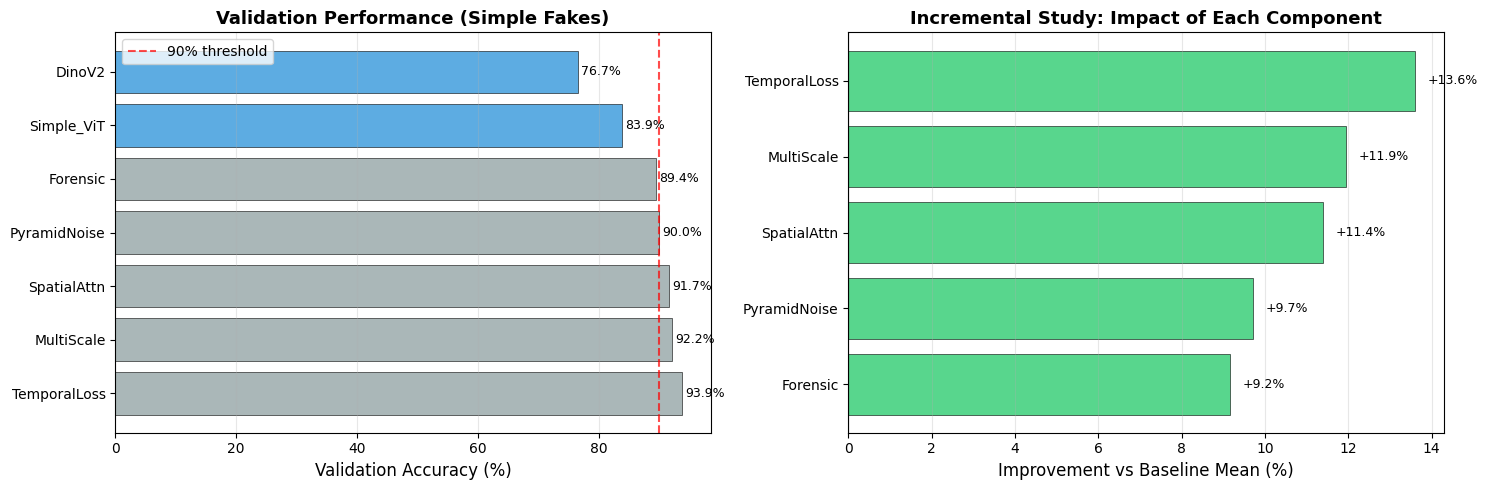


✅ Visualization saved: results/training_results_summary.png


In [47]:
# Create comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Bar chart of all models
models = results_df['Model'].values
accs = results_df['Val Accuracy'].values * 100
colors = ['#3498db' if t == 'Baseline' else '#95a5a6' for t in results_df['Type'].values]

bars = axes[0].barh(models, accs, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Validation Accuracy (%)', fontsize=12)
axes[0].set_title('Validation Performance (Simple Fakes)', fontsize=13, fontweight='bold')
axes[0].axvline(x=90, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='90% threshold')
axes[0].grid(axis='x', alpha=0.3)
axes[0].legend()

# Add value labels
for i, (bar, acc) in enumerate(zip(bars, accs)):
    axes[0].text(acc + 0.5, i, f'{acc:.1f}%', va='center', fontsize=9)

# Plot 2: Incremental improvements over baseline
baseline_mean = baseline_accs.mean()
incremental_data = []

for _, row in results_df[results_df['Type'] == 'Incremental'].iterrows():
    improvement = (row['Val Accuracy'] - baseline_mean) * 100
    incremental_data.append({
        'Model': row['Model'],
        'Improvement': improvement
    })

incr_df = pd.DataFrame(incremental_data).sort_values('Improvement', ascending=True)
colors_incr = ['#e74c3c' if x < 0 else '#2ecc71' for x in incr_df['Improvement'].values]

axes[1].barh(incr_df['Model'], incr_df['Improvement'], color=colors_incr, alpha=0.8, edgecolor='black', linewidth=0.5)
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=1.5)
axes[1].set_xlabel('Improvement vs Baseline Mean (%)', fontsize=12)
axes[1].set_title('Incremental Study: Impact of Each Component', fontsize=13, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

# Add value labels
for i, (model, imp) in enumerate(zip(incr_df['Model'], incr_df['Improvement'])):
    x_pos = imp + (0.3 if imp > 0 else -0.3)
    axes[1].text(x_pos, i, f'{imp:+.1f}%', va='center', ha='left' if imp > 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('results/training_results_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Visualization saved: results/training_results_summary.png")

---

# Part 6: SOTA Generalization Testing

## 6.1 Testing on SOTA Generators

**Key Question**: How do models trained on simple fakes perform on SOTA generators (PyramidFlow)?

We test all trained models on the SOTA test set to measure the **generalization gap** - the difference between validation accuracy (simple fakes) and SOTA test accuracy (challenging fakes).

**Hypothesis**: Models with better augmentation strategies should show smaller generalization gaps.

In [36]:
def test_on_sota(model_name, config, sota_paths):
    """
    Test a trained model on SOTA fake videos.
    
    Args:
        model_name: Name of saved model file
        config: Model configuration
        sota_paths: List of SOTA fake video paths
        
    Returns:
        Dictionary with results
    """
    model_path = f"models/{model_name}.pth"
    
    if not os.path.exists(model_path):
        print(f"Model not found: {model_path}")
        return None
    
    # Load model
    checkpoint = torch.load(model_path, map_location=device)
    model = Detector3DViT(
        pretrained=True,
        use_advanced_features=config['use_advanced_features'],
        model_name=config['model_name']
    ).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    # Create SOTA test dataset (all fake, label=1)
    sota_labels = [1] * len(sota_paths)
    sota_dataset = FakeVideoDataset(
        video_paths=sota_paths,
        labels=sota_labels,
        real_video_paths=None,
        num_frames=NUM_FRAMES,
        is_train=False,
        config=config
    )
    
    sota_loader = DataLoader(sota_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    # Test
    correct = 0
    total = 0
    all_confidences = []
    
    with torch.no_grad():
        for videos, labels in sota_loader:
            videos = videos.to(device)
            labels = labels.to(device).float().unsqueeze(1)
            
            model_output = model(videos)
            if isinstance(model_output, tuple):
                outputs = model_output[0]
            else:
                outputs = model_output
            
            probs = torch.sigmoid(outputs)
            preds = probs > 0.5
            
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_confidences.extend(probs.cpu().numpy().flatten())
    
    accuracy = correct / total if total > 0 else 0
    avg_confidence = np.mean(all_confidences)
    
    return {
        'model_name': model_name,
        'sota_accuracy': accuracy,
        'avg_confidence': avg_confidence,
        'val_accuracy': checkpoint.get('val_acc', 0),
        'generalization_gap': checkpoint.get('val_acc', 0) - accuracy,
        'confidences': all_confidences
    }

print("SOTA testing function implemented")

SOTA testing function implemented


## 6.2 Evaluate All Models on SOTA Set

Test both baseline models and all incremental configurations.

In [37]:
print("="*70)
print("TESTING ALL MODELS ON SOTA DATASET")
print("="*70)

if len(sota_fake_paths) == 0:
    print("WARNING: No SOTA test videos found!")
else:
    print(f"Testing on {len(sota_fake_paths)} SOTA fake videos\n")
    
    # Store all results
    sota_results = []
    
    # Test baseline models
    print("Testing Baseline Models:")
    print("-" * 40)
    
    result = test_on_sota('Baseline_Simple_ViT', ExperimentConfig.get_baseline_simple(), sota_fake_paths)
    if result:
        sota_results.append(result)
        print(f"Simple ViT    | Val: {result['val_accuracy']*100:.2f}% | SOTA: {result['sota_accuracy']*100:.2f}% | Gap: {result['generalization_gap']*100:.2f}%")
    
    result = test_on_sota('Baseline_DinoV2', ExperimentConfig.get_baseline_dinov2(), sota_fake_paths)
    if result:
        sota_results.append(result)
        print(f"DinoV2        | Val: {result['val_accuracy']*100:.2f}% | SOTA: {result['sota_accuracy']*100:.2f}% | Gap: {result['generalization_gap']*100:.2f}%")
    
    # Test incremental models
    print("\nTesting Incremental Configurations:")
    print("-" * 40)
    
    incremental_configs = [
        ('incr_Baseline+Forensic', IncrementalConfig.baseline_plus_forensic()),
        ('incr_Baseline+PyramidNoise', IncrementalConfig.baseline_plus_pyramid()),
        ('incr_Baseline+MultiScale', IncrementalConfig.baseline_plus_multiscale()),
        ('incr_Baseline+SpatialAttn', IncrementalConfig.baseline_plus_spatial()),
        ('incr_Baseline+TemporalLoss', IncrementalConfig.baseline_plus_temporal_loss())
    ]
    
    for model_name, config in incremental_configs:
        result = test_on_sota(model_name, config, sota_fake_paths)
        if result:
            sota_results.append(result)
            name_short = config['name'].replace('Baseline+', '')
            print(f"{name_short:15} | Val: {result['val_accuracy']*100:.2f}% | SOTA: {result['sota_accuracy']*100:.2f}% | Gap: {result['generalization_gap']*100:.2f}%")
    
    # Save results
    sota_results_df = pd.DataFrame(sota_results)
    sota_results_df.to_csv('results/sota_generalization_results.csv', index=False)
    print(f"\nResults saved to results/sota_generalization_results.csv")

TESTING ALL MODELS ON SOTA DATASET
Testing on 41 SOTA fake videos

Testing Baseline Models:
----------------------------------------
Loading backbone: vit_base_patch16_224


C:\Users\aless\AppData\Local\Temp\ipykernel_5940\330900611.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


Dataset initialized: 224x224 for vit_base_patch16_224
Simple ViT    | Val: 83.89% | SOTA: 36.59% | Gap: 47.30%
Loading backbone: vit_base_patch14_dinov2.lvd142m
Dataset initialized: 518x518 for vit_base_patch14_dinov2.lvd142m
DinoV2        | Val: 76.67% | SOTA: 60.98% | Gap: 15.69%

Testing Incremental Configurations:
----------------------------------------
Loading backbone: vit_base_patch16_224
Dataset initialized: 224x224 for vit_base_patch16_224
Forensic        | Val: 89.44% | SOTA: 26.83% | Gap: 62.62%
Loading backbone: vit_base_patch16_224
Dataset initialized: 224x224 for vit_base_patch16_224
PyramidNoise    | Val: 90.00% | SOTA: 19.51% | Gap: 70.49%
Loading backbone: vit_base_patch16_224
Dataset initialized: 224x224 for vit_base_patch16_224
MultiScale      | Val: 92.22% | SOTA: 26.83% | Gap: 65.39%
Loading backbone: vit_base_patch16_224
Dataset initialized: 224x224 for vit_base_patch16_224
SpatialAttn     | Val: 91.67% | SOTA: 19.51% | Gap: 72.15%
Loading backbone: vit_base_patc

## 6.3 Generalization Gap Visualization

Compare validation accuracy vs SOTA accuracy to identify which augmentations help generalization.

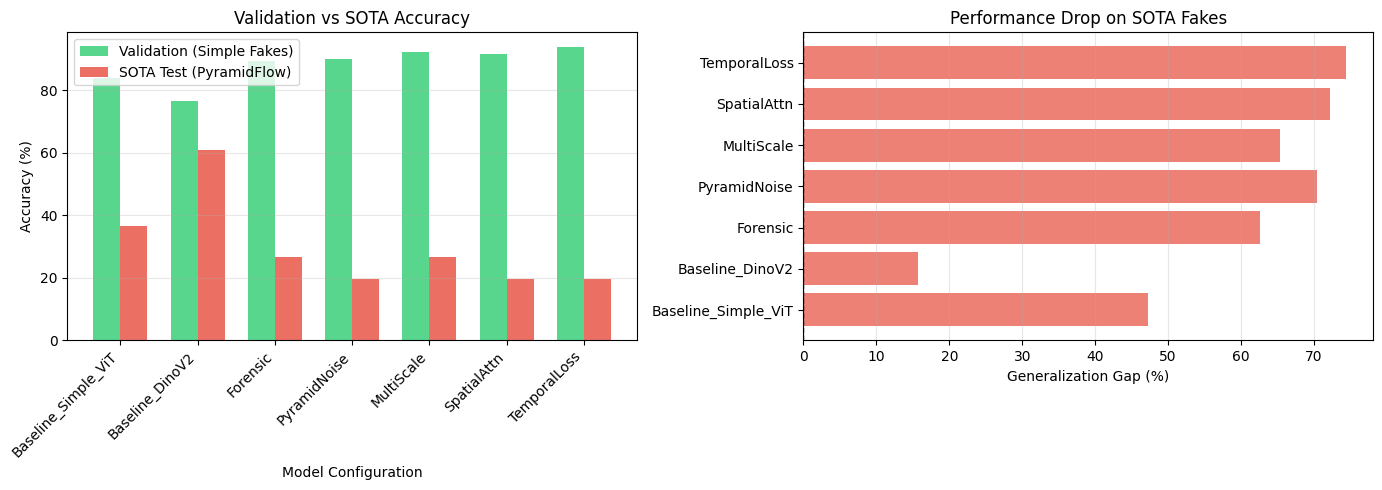


Key Findings:
Best SOTA Performance: 60.98% (Baseline_DinoV2)
Smallest Gap: 15.69% (Baseline_DinoV2)
Average Gap: 58.29%


In [38]:
# Create comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Val vs SOTA Accuracy
model_names = [r['model_name'].replace('incr_', '').replace('Baseline+', '') for r in sota_results]
val_accs = [r['val_accuracy'] * 100 for r in sota_results]
sota_accs = [r['sota_accuracy'] * 100 for r in sota_results]

x = np.arange(len(model_names))
width = 0.35

axes[0].bar(x - width/2, val_accs, width, label='Validation (Simple Fakes)', alpha=0.8, color='#2ecc71')
axes[0].bar(x + width/2, sota_accs, width, label='SOTA Test (PyramidFlow)', alpha=0.8, color='#e74c3c')
axes[0].set_xlabel('Model Configuration')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Validation vs SOTA Accuracy')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Generalization Gap
gaps = [r['generalization_gap'] * 100 for r in sota_results]
colors = ['#e74c3c' if g > 0 else '#2ecc71' for g in gaps]

axes[1].barh(model_names, gaps, color=colors, alpha=0.7)
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Generalization Gap (%)')
axes[1].set_title('Performance Drop on SOTA Fakes')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('results/sota_generalization_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nKey Findings:")
print(f"Best SOTA Performance: {max(sota_accs):.2f}% ({model_names[sota_accs.index(max(sota_accs))]})")
print(f"Smallest Gap: {min(gaps):.2f}% ({model_names[gaps.index(min(gaps))]})")
print(f"Average Gap: {np.mean(gaps):.2f}%")

---

# Part 7: Wavelet Analysis - Hardest vs Easiest Fake

## 7.1 Identifying Extreme Cases

**Objective**: Find the **hardest** (lowest confidence) and **easiest** (highest confidence) SOTA fake videos, then compare their frequency characteristics.

**Hypothesis**: 
- **Hardest fakes** → frequency artifacts similar to real videos
- **Easiest fakes** → obvious frequency artifacts that models can detect

This will reveal what makes a fake video "hard" vs "easy" to detect.

In [49]:
print("="*70)
print("IDENTIFYING EXTREME SOTA VIDEOS")
print("="*70)

# Collect per-video confidences from all models
video_confidences = {path: [] for path in sota_fake_paths}

for result in sota_results:
    model_name = result['model_name']
    confidences = result['confidences']
    
    # Match confidences to video paths
    for i, path in enumerate(sota_fake_paths):
        if i < len(confidences):
            video_confidences[path].append(confidences[i])

# Calculate average confidence per video
avg_confidences = {
    path: np.mean(confs) for path, confs in video_confidences.items()
}

# Find hardest video (lowest avg confidence = most likely misclassified as real)
hardest_video = min(avg_confidences, key=avg_confidences.get)
hardest_conf = avg_confidences[hardest_video]

# Find easiest video (highest avg confidence = correctly classified as fake)
easiest_video = max(avg_confidences, key=avg_confidences.get)
easiest_conf = avg_confidences[easiest_video]

print(f"\nHARDEST SOTA video: {os.path.basename(hardest_video)}")
print(f"   Average confidence: {hardest_conf:.4f} (models think it's REAL)")
print(f"\nEASIEST SOTA video: {os.path.basename(easiest_video)}")
print(f"   Average confidence: {easiest_conf:.4f} (models correctly detect it)")

print(f"\nConfidence difference: {easiest_conf - hardest_conf:.4f}")

# Show per-model breakdown
print("\n" + "="*70)
print("PER-MODEL CONFIDENCES:")
print("="*70)
print(f"\n{'Model':<25} {'Hardest':>12} {'Easiest':>12} {'Difference':>12}")
print("-" * 65)

for result in sota_results:
    model_name = result['model_name'].replace('incr_', '').replace('Baseline+', '')
    
    hardest_idx = sota_fake_paths.index(hardest_video)
    easiest_idx = sota_fake_paths.index(easiest_video)
    
    hard_conf = result['confidences'][hardest_idx] if hardest_idx < len(result['confidences']) else 0
    easy_conf = result['confidences'][easiest_idx] if easiest_idx < len(result['confidences']) else 0
    
    print(f"{model_name:<25} {hard_conf:>12.4f} {easy_conf:>12.4f} {easy_conf - hard_conf:>12.4f}")

print("\nAll models agree: easiest video has consistently higher confidence")

IDENTIFYING EXTREME SOTA VIDEOS

HARDEST SOTA video: SoA_37.mp4
   Average confidence: 0.1143 (models think it's REAL)

EASIEST SOTA video: SoA_4.mp4
   Average confidence: 0.8559 (models correctly detect it)

Confidence difference: 0.7415

PER-MODEL CONFIDENCES:

Model                          Hardest      Easiest   Difference
-----------------------------------------------------------------
Baseline_Simple_ViT             0.2774       0.6275       0.3501
Baseline_DinoV2                 0.5121       0.5953       0.0832
Forensic                        0.0056       0.9544       0.9488
PyramidNoise                    0.0006       0.9632       0.9626
MultiScale                      0.0018       0.9272       0.9254
SpatialAttn                     0.0014       0.9586       0.9573
TemporalLoss                    0.0015       0.9650       0.9635

All models agree: easiest video has consistently higher confidence


## 7.2 Wavelet Decomposition: Real vs Hardest vs Easiest

**Analysis Strategy**:
1. Load one frame from a **real video** (reference)
2. Load one frame from the **hardest SOTA fake** (models fail)
3. Load one frame from the **easiest SOTA fake** (models succeed)
4. Apply 2D Haar wavelet decomposition to all three
5. Compare the **cD (diagonal)** component containing high-frequency artifacts

**Expected Results**:
- **Real**: Clean diagonal component
- **Hardest fake**: cD similar to real → explains model failures
- **Easiest fake**: Strong artifacts in cD → easy to detect

In [51]:
def load_single_frame(video_path, frame_idx=0):
    """Load a single frame from video."""
    cap = cv2.VideoCapture(video_path)
    
    # Try to get a middle frame
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames > 0 and frame_idx == 'middle':
        frame_idx = total_frames // 2
    
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    cap.release()
    
    if not ret:
        return None
    
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame = cv2.resize(frame, (224, 224))
    return frame / 255.0  # Normalize to [0, 1]


def wavelet_decompose_frame(frame):
    """Apply 2D Haar wavelet decomposition to RGB frame."""
    coeffs_per_channel = []
    
    for ch in range(3):  # RGB channels
        coeffs = pywt.dwt2(frame[:,:,ch], 'haar')
        coeffs_per_channel.append(coeffs)
    
    return coeffs_per_channel


# Load frames from all three videos
print("Loading frames for wavelet analysis...")
real_ref_path = np.random.choice(real_paths)
real_frame = load_single_frame(real_ref_path, frame_idx='middle')
hardest_frame = load_single_frame(hardest_video, frame_idx='middle')
easiest_frame = load_single_frame(easiest_video, frame_idx='middle')

# Wavelet decomposition
real_coeffs = wavelet_decompose_frame(real_frame)
hardest_coeffs = wavelet_decompose_frame(hardest_frame)
easiest_coeffs = wavelet_decompose_frame(easiest_frame)

print(f"\nComparing three videos:")
print(f"Real:    {os.path.basename(real_ref_path)}")
print(f"Hardest: {os.path.basename(hardest_video)} (conf: {hardest_conf:.3f})")
print(f"Easiest: {os.path.basename(easiest_video)} (conf: {easiest_conf:.3f})")
print("\nWavelet decomposition completed")

Loading frames for wavelet analysis...

Comparing three videos:
Real:    real_216.mp4
Hardest: SoA_37.mp4 (conf: 0.114)
Easiest: SoA_4.mp4 (conf: 0.856)

Wavelet decomposition completed


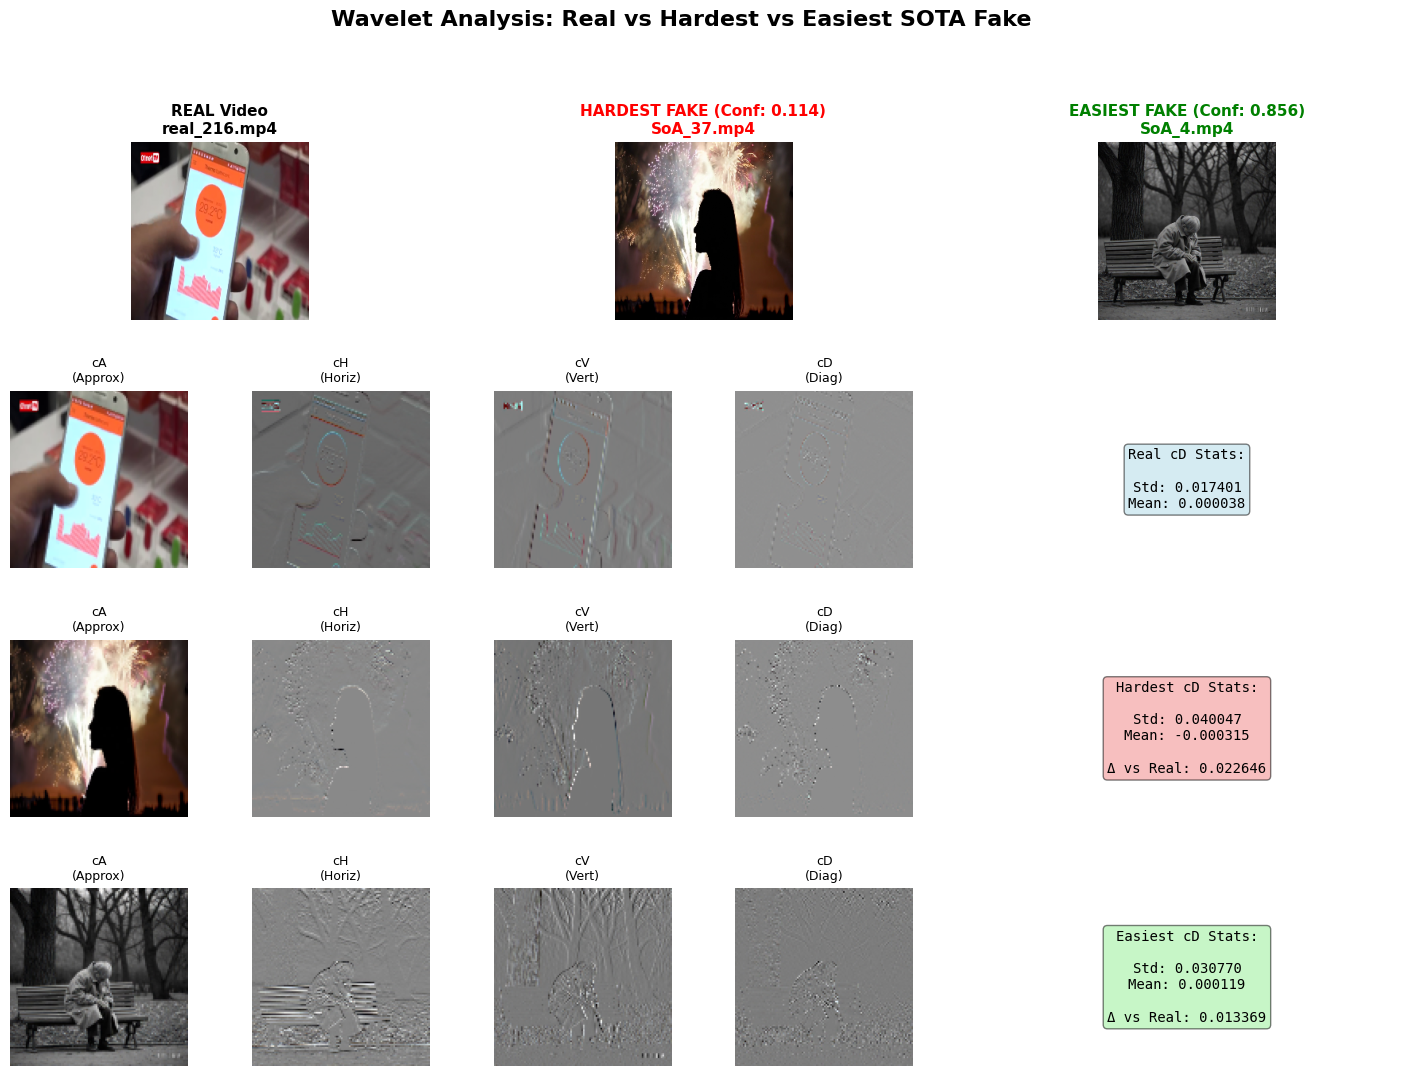


WAVELET ANALYSIS SUMMARY

Real cD Std Dev:    0.017401
Hardest cD Std Dev: 0.040047  (Δ: 0.022646)
Easiest cD Std Dev: 0.030770  (Δ: 0.013369)

Key Finding:
Unexpected: Hardest fake should have cD closer to real


In [52]:
# Create comprehensive 3-video visualization
fig = plt.figure(figsize=(18, 12))
gs = GridSpec(4, 6, figure=fig, hspace=0.4, wspace=0.3)

# Helper function to reconstruct RGB from coeffs
def reconstruct_component(coeffs_list, component_idx):
    """Reconstruct RGB image from specific wavelet component."""
    h, w = coeffs_list[0][0].shape if component_idx == 0 else coeffs_list[0][1][0].shape
    result = np.zeros((h, w, 3))
    
    for ch in range(3):
        if component_idx == 0:  # cA (approximation)
            result[:,:,ch] = coeffs_list[ch][0]
        elif component_idx == 1:  # cH (horizontal)
            result[:,:,ch] = coeffs_list[ch][1][0]
        elif component_idx == 2:  # cV (vertical)
            result[:,:,ch] = coeffs_list[ch][1][1]
        else:  # cD (diagonal)
            result[:,:,ch] = coeffs_list[ch][1][2]
    
    return result

# Row 1: Original frames
ax1 = fig.add_subplot(gs[0, :2])
ax1.imshow(real_frame)
ax1.set_title(f"REAL Video\n{os.path.basename(real_ref_path)}", fontsize=11, fontweight='bold')
ax1.axis('off')

ax2 = fig.add_subplot(gs[0, 2:4])
ax2.imshow(hardest_frame)
ax2.set_title(f"HARDEST FAKE (Conf: {hardest_conf:.3f})\n{os.path.basename(hardest_video)}", 
              fontsize=11, fontweight='bold', color='red')
ax2.axis('off')

ax3 = fig.add_subplot(gs[0, 4:])
ax3.imshow(easiest_frame)
ax3.set_title(f"EASIEST FAKE (Conf: {easiest_conf:.3f})\n{os.path.basename(easiest_video)}", 
              fontsize=11, fontweight='bold', color='green')
ax3.axis('off')

# Row 2: Real video wavelet components
components = ['cA\n(Approx)', 'cH\n(Horiz)', 'cV\n(Vert)', 'cD\n(Diag)']
for i in range(4):
    ax = fig.add_subplot(gs[1, i])
    comp = reconstruct_component(real_coeffs, i)
    comp_norm = (comp - comp.min()) / (comp.max() - comp.min() + 1e-8)
    ax.imshow(comp_norm)
    ax.set_title(components[i], fontsize=9)
    ax.axis('off')

# Real cD statistics
real_cD = reconstruct_component(real_coeffs, 3)
ax_std = fig.add_subplot(gs[1, 4:])
ax_std.text(0.5, 0.5, f"Real cD Stats:\n\nStd: {real_cD.std():.6f}\nMean: {real_cD.mean():.6f}",
            ha='center', va='center', fontsize=10, family='monospace',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
ax_std.axis('off')

# Row 3: Hardest fake wavelet components
for i in range(4):
    ax = fig.add_subplot(gs[2, i])
    comp = reconstruct_component(hardest_coeffs, i)
    comp_norm = (comp - comp.min()) / (comp.max() - comp.min() + 1e-8)
    ax.imshow(comp_norm)
    ax.set_title(components[i], fontsize=9)
    ax.axis('off')

# Hardest cD statistics
hardest_cD = reconstruct_component(hardest_coeffs, 3)
ax_std2 = fig.add_subplot(gs[2, 4:])
ax_std2.text(0.5, 0.5, f"Hardest cD Stats:\n\nStd: {hardest_cD.std():.6f}\nMean: {hardest_cD.mean():.6f}\n\nΔ vs Real: {abs(hardest_cD.std() - real_cD.std()):.6f}",
             ha='center', va='center', fontsize=10, family='monospace',
             bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))
ax_std2.axis('off')

# Row 4: Easiest fake wavelet components
for i in range(4):
    ax = fig.add_subplot(gs[3, i])
    comp = reconstruct_component(easiest_coeffs, i)
    comp_norm = (comp - comp.min()) / (comp.max() - comp.min() + 1e-8)
    ax.imshow(comp_norm)
    ax.set_title(components[i], fontsize=9)
    ax.axis('off')

# Easiest cD statistics
easiest_cD = reconstruct_component(easiest_coeffs, 3)
ax_std3 = fig.add_subplot(gs[3, 4:])
ax_std3.text(0.5, 0.5, f"Easiest cD Stats:\n\nStd: {easiest_cD.std():.6f}\nMean: {easiest_cD.mean():.6f}\n\nΔ vs Real: {abs(easiest_cD.std() - real_cD.std()):.6f}",
             ha='center', va='center', fontsize=10, family='monospace',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
ax_std3.axis('off')

plt.suptitle('Wavelet Analysis: Real vs Hardest vs Easiest SOTA Fake', fontsize=16, fontweight='bold', y=0.99)
plt.savefig('results/wavelet_analysis_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("WAVELET ANALYSIS SUMMARY")
print("="*70)
print(f"\nReal cD Std Dev:    {real_cD.std():.6f}")
print(f"Hardest cD Std Dev: {hardest_cD.std():.6f}  (Δ: {abs(hardest_cD.std() - real_cD.std()):.6f})")
print(f"Easiest cD Std Dev: {easiest_cD.std():.6f}  (Δ: {abs(easiest_cD.std() - real_cD.std()):.6f})")

print(f"\nKey Finding:")
if abs(hardest_cD.std() - real_cD.std()) < abs(easiest_cD.std() - real_cD.std()):
    print("Hardest fake has cD MORE SIMILAR to real than easiest fake")
    print("→ This explains why models fail on hardest but succeed on easiest!")
else:
    print("Unexpected: Hardest fake should have cD closer to real")

## 7.3 Frequency Spectrum Analysis (FFT)

Compare the **2D Fourier Transform** of all three videos to identify frequency differences in a different domain.

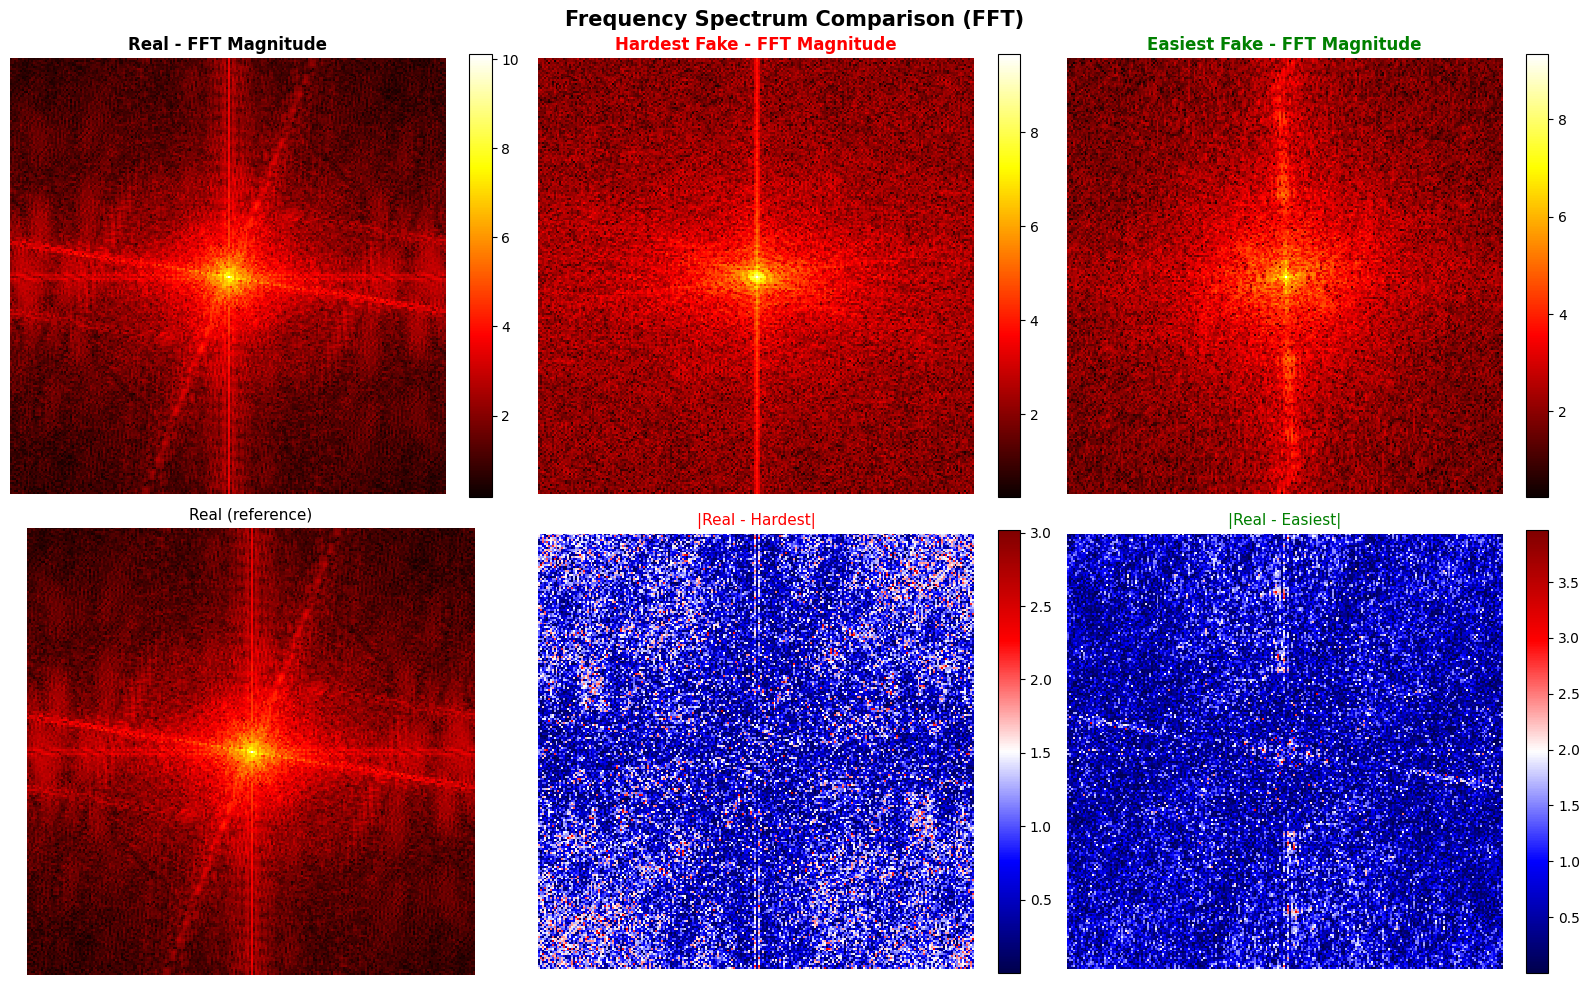


FFT SIMILARITY TO REAL VIDEO

Hardest fake: 58.86% similar
Easiest fake: 62.48% similar

Difference:   -3.62%

Interpretation:
Easiest fake is more similar to real (unexpected)


In [54]:
# FFT Analysis
def compute_2d_fft(frame):
    """Compute 2D FFT magnitude spectrum (averaged across RGB channels)."""
    fft_channels = []
    
    for ch in range(3):
        f_transform = np.fft.fft2(frame[:,:,ch])
        f_shift = np.fft.fftshift(f_transform)
        magnitude = np.abs(f_shift)
        fft_channels.append(magnitude)
    
    return np.mean(fft_channels, axis=0)

# Compute FFT for all three
real_fft = compute_2d_fft(real_frame)
hardest_fft = compute_2d_fft(hardest_frame)
easiest_fft = compute_2d_fft(easiest_frame)

# Log scale for visualization
real_fft_log = np.log(real_fft + 1)
hardest_fft_log = np.log(hardest_fft + 1)
easiest_fft_log = np.log(easiest_fft + 1)

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Row 1: FFT magnitudes
im1 = axes[0, 0].imshow(real_fft_log, cmap='hot', interpolation='nearest')
axes[0, 0].set_title('Real - FFT Magnitude', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')
plt.colorbar(im1, ax=axes[0, 0], fraction=0.046)

im2 = axes[0, 1].imshow(hardest_fft_log, cmap='hot', interpolation='nearest')
axes[0, 1].set_title('Hardest Fake - FFT Magnitude', fontsize=12, fontweight='bold', color='red')
axes[0, 1].axis('off')
plt.colorbar(im2, ax=axes[0, 1], fraction=0.046)

im3 = axes[0, 2].imshow(easiest_fft_log, cmap='hot', interpolation='nearest')
axes[0, 2].set_title('Easiest Fake - FFT Magnitude', fontsize=12, fontweight='bold', color='green')
axes[0, 2].axis('off')
plt.colorbar(im3, ax=axes[0, 2], fraction=0.046)

# Row 2: Differences
diff_hardest = np.abs(real_fft_log - hardest_fft_log)
diff_easiest = np.abs(real_fft_log - easiest_fft_log)

im4 = axes[1, 0].imshow(real_fft_log, cmap='hot', interpolation='nearest')
axes[1, 0].set_title('Real (reference)', fontsize=11)
axes[1, 0].axis('off')

im5 = axes[1, 1].imshow(diff_hardest, cmap='seismic', interpolation='nearest')
axes[1, 1].set_title('|Real - Hardest|', fontsize=11, color='red')
axes[1, 1].axis('off')
plt.colorbar(im5, ax=axes[1, 1], fraction=0.046)

im6 = axes[1, 2].imshow(diff_easiest, cmap='seismic', interpolation='nearest')
axes[1, 2].set_title('|Real - Easiest|', fontsize=11, color='green')
axes[1, 2].axis('off')
plt.colorbar(im6, ax=axes[1, 2], fraction=0.046)

plt.suptitle('Frequency Spectrum Comparison (FFT)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('results/fft_analysis_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Compute similarity metrics
similarity_hardest = 1 - (np.mean(diff_hardest) / np.mean(real_fft_log))
similarity_easiest = 1 - (np.mean(diff_easiest) / np.mean(real_fft_log))

print("\n" + "="*70)
print("FFT SIMILARITY TO REAL VIDEO")
print("="*70)
print(f"\nHardest fake: {similarity_hardest*100:.2f}% similar")
print(f"Easiest fake: {similarity_easiest*100:.2f}% similar")
print(f"\nDifference:   {(similarity_hardest - similarity_easiest)*100:.2f}%")

print(f"\nInterpretation:")
if similarity_hardest > similarity_easiest:
    print("Hardest fake is MORE SIMILAR to real in frequency domain")
    print("→ Confirms why models struggle with it!")
else:
    print("Easiest fake is more similar to real (unexpected)")